# EcoLocator on Douglas-fir: Demo

This notebook walks through a leave-one-out (LOO) cross-validation analysis of Douglas-fir (*Pseudotsuga menziesii*) using EcoLocator, and digs into what the model's SHAP attributions reveal about the genetic basis of local adaptation in this species.

**This notebook does not retrain anything.** All predictions and SHAP values shown here were computed previously (via the `ecolocator` CLI, run as a Slurm array job — one train/predict/attribute cycle per held-out sample). This notebook loads and interprets those already-computed results.

For installation and a walkthrough of the CLI and Python API, see {doc}`/installation` and {doc}`/getting-started-python`.


## Data & methods

- **Genotypes**: an Axiom 54K SNP array, genotyped across the sampled individuals.
- **Sample metadata**: geographic origin (`x` = longitude, `y` = latitude) plus three environmental covariates derived from ClimateNA:
  - `cov1` — **MCMT**, mean coldest-month temperature (°C)
  - `cov2` — **SHM**, summer heat:moisture index
  - `cov3` — **MSP**, mean summer precipitation (mm)
- **Validation**: leave-one-out cross-validation across 348 individuals with known coordinates — each individual held out once, a fresh model trained on the rest, then predicted and SHAP-attributed.

Two output files came out of the aggregation step: predicted-vs-true values per individual, and mean |SHAP| per SNP per output variable (averaged across all 348 LOO folds).

In [ ]:
import pandas as pd
import numpy as np
from IPython.display import Image, display

COV_LABELS = {
    "x": "Longitude",
    "y": "Latitude",
    "cov1": "MCMT (mean coldest-month temp, \u00b0C)",
    "cov2": "SHM (summer heat:moisture index)",
    "cov3": "MSP (mean summer precip, mm)",
}
VARIABLES = ["x", "y", "cov1", "cov2", "cov3"]

## How well does genotype predict location and climate-of-origin?

In [ ]:
def r2(true, pred):
    ss_res = np.sum((true - pred) ** 2)
    ss_tot = np.sum((true - np.mean(true)) ** 2)
    return 1 - ss_res / ss_tot


preds = pd.read_csv("loo_predictions_merged.tsv", sep="\t")
print(f"{len(preds)} individuals, each held out exactly once during LOO cross-validation.\n")

for var in VARIABLES:
    rv = r2(preds[f"{var}_true"], preds[var])
    print(f"{var:6s}  {COV_LABELS[var]:38s}  R\u00b2 = {rv:.3f}")

348 individuals, each held out exactly once during LOO cross-validation.

x       Longitude                               R² = 0.749
y       Latitude                                R² = 0.829
cov1    MCMT (mean coldest-month temp, °C)      R² = 0.721
cov2    SHM (summer heat:moisture index)        R² = 0.516
cov3    MSP (mean summer precip, mm)            R² = 0.544


Predicted vs. true, for each of the five output variables, across all 348 LOO folds:

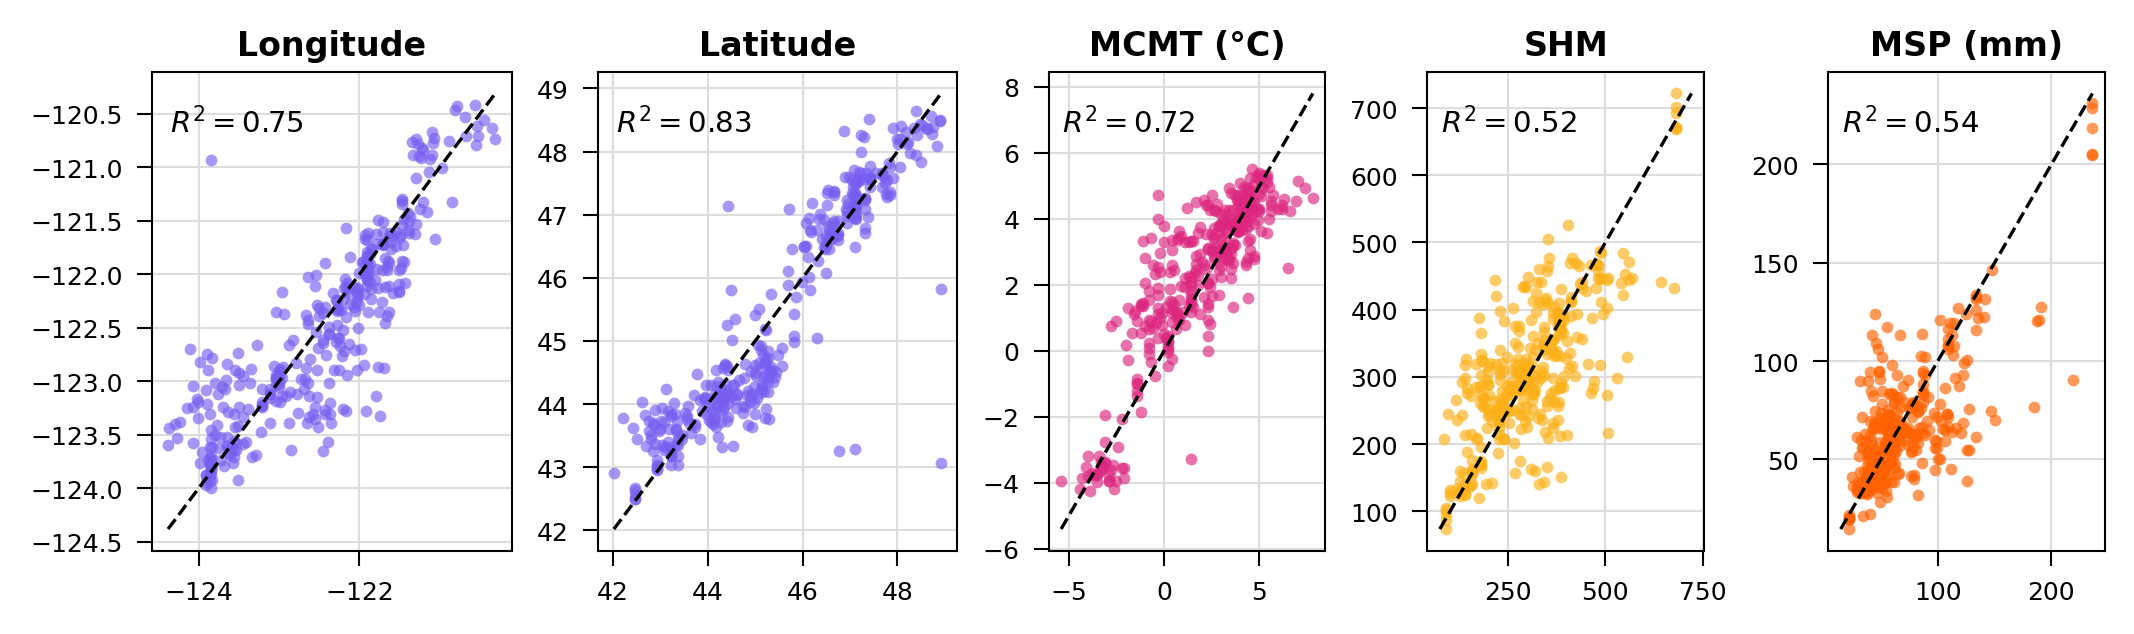

In [ ]:
display(Image(filename="predictions_vs_true.png"))

Latitude is predicted the most accurately, with the climate covariates — especially MCMT — close behind. That raises the natural next question: *which loci are actually driving these predictions, and is it the same genetic signal behind all five, or something more specific to each?*

## Which SNPs is the model actually using?

SHAP attribution was run for every held-out individual and averaged across all 348 folds, giving one mean |SHAP| value per SNP, per output variable. The figure below plots those values in genomic order, with the top 1% of SNPs (by SHAP magnitude) highlighted for each variable.

18932 SNPs retained after QC filtering.


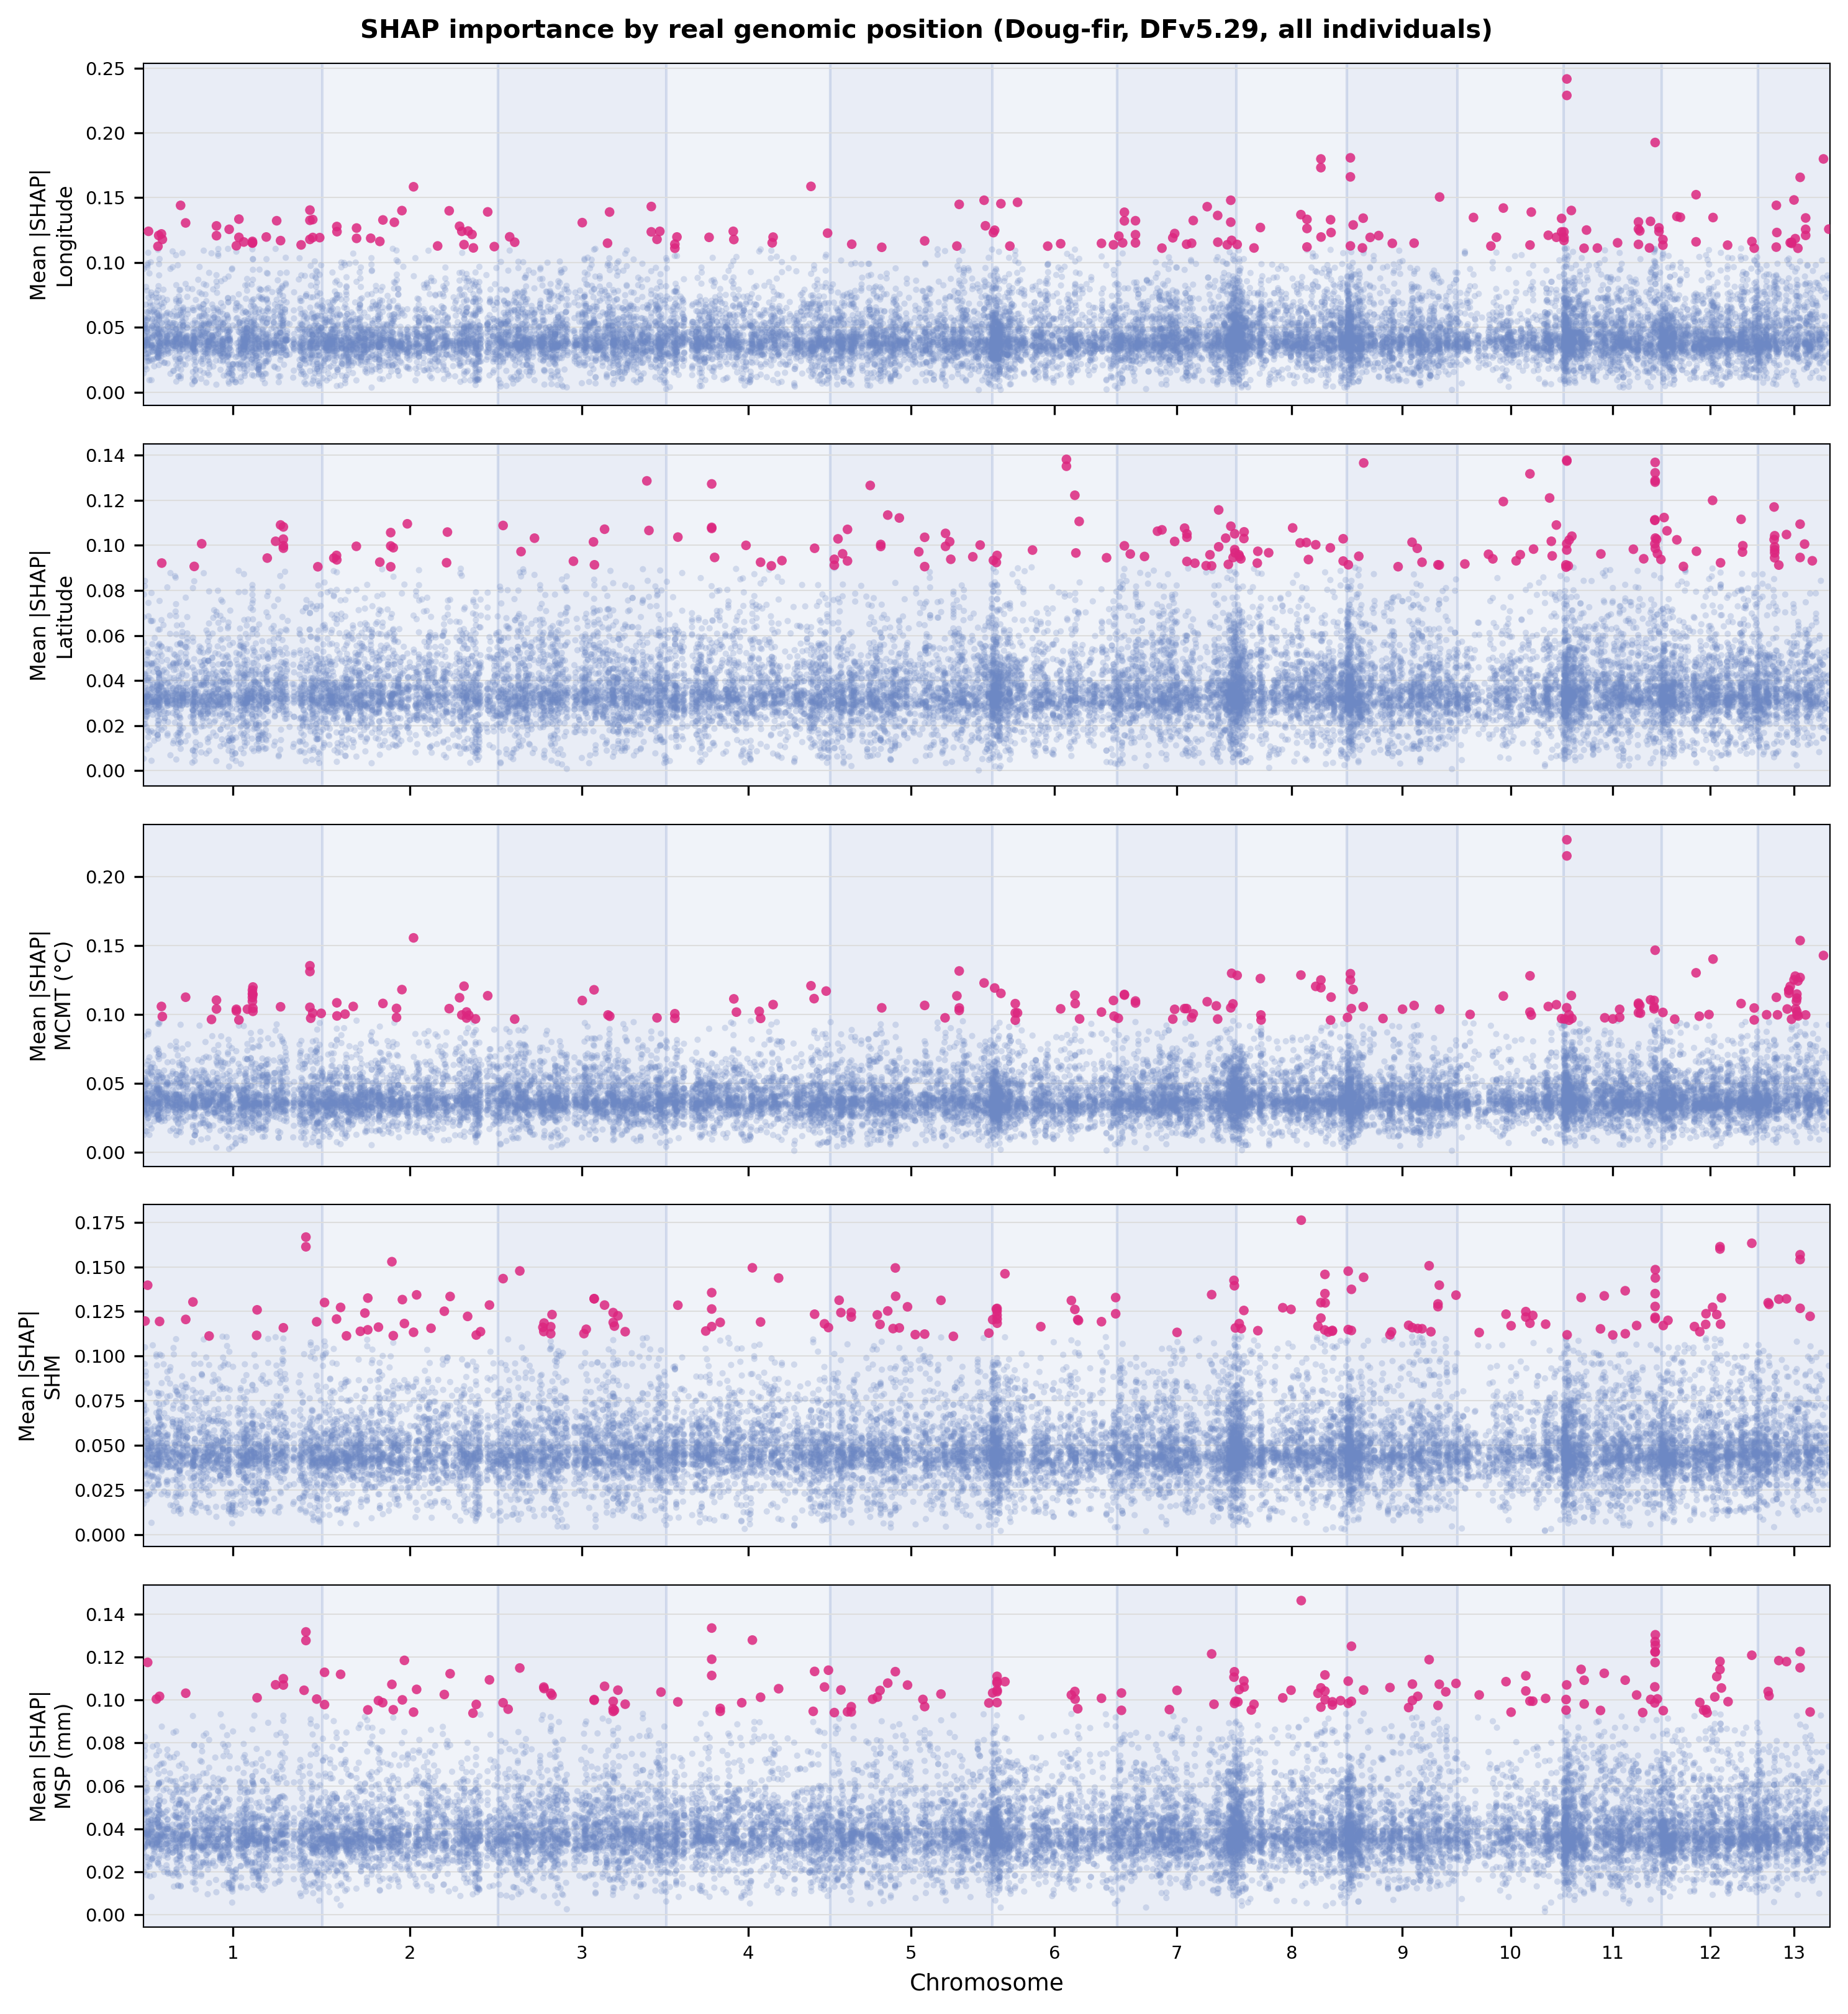

In [ ]:
shap_df = pd.read_csv("loo_shap_mean_by_snp.tsv", sep="\t")
print(f"{len(shap_df)} SNPs retained after QC filtering.")

display(Image(filename="shap_manhattan_dfir_positional.png"))

## Do the top loci overlap across variables?

This is the key disentangling question for any landscape-genomics model: population structure and environment are often correlated across geography, so a locus that matters for climate prediction *could* just be riding along with the same broad genetic cline that predicts location. But overlap by itself doesn't automatically mean "non-adaptive" — it can also mean the environmental gradient genuinely tracks that geographic axis in this species' actual range. So the right move is to check the overlap *and* interpret it against what's known about the species' biogeography, rather than treat any overlap as a red flag.

We can check this directly: take the top 1% of SNPs (by mean |SHAP|) for each variable, and measure how much those sets overlap.

In [ ]:
n_top = max(1, round(0.01 * len(shap_df)))
top_sets = {var: set(shap_df.nlargest(n_top, var)["snp_id"]) for var in VARIABLES}

print(f"Top 1% = {n_top} SNPs per variable\n")

print("Overlap between latitude (y) and each climate covariate:")
for cov in ["cov1", "cov2", "cov3"]:
    n_shared = len(top_sets["y"] & top_sets[cov])
    print(f"  y vs {cov} ({COV_LABELS[cov]:38s}): {n_shared:3d} shared SNPs ({n_shared / n_top:.0%} of top set)")

print("\nOverlap between longitude (x) and each climate covariate:")
for cov in ["cov1", "cov2", "cov3"]:
    n_shared = len(top_sets["x"] & top_sets[cov])
    print(f"  x vs {cov} ({COV_LABELS[cov]:38s}): {n_shared:3d} shared SNPs ({n_shared / n_top:.0%} of top set)")

print("\nOverlap among the three climate covariates themselves:")
for a, b in [("cov1", "cov2"), ("cov1", "cov3"), ("cov2", "cov3")]:
    n_shared = len(top_sets[a] & top_sets[b])
    print(f"  {a} vs {b}: {n_shared:3d} shared SNPs ({n_shared / n_top:.0%})")

Top 1% = 189 SNPs per variable

Overlap between latitude (y) and each climate covariate:
  y vs cov1 (MCMT (mean coldest-month temp, °C)    ):  15 shared SNPs (8% of top set)
  y vs cov2 (SHM (summer heat:moisture index)      ):  32 shared SNPs (17% of top set)
  y vs cov3 (MSP (mean summer precip, mm)          ):  35 shared SNPs (19% of top set)

Overlap between longitude (x) and each climate covariate:
  x vs cov1 (MCMT (mean coldest-month temp, °C)    ): 103 shared SNPs (54% of top set)
  x vs cov2 (SHM (summer heat:moisture index)      ):   4 shared SNPs (2% of top set)
  x vs cov3 (MSP (mean summer precip, mm)          ):   5 shared SNPs (3% of top set)

Overlap among the three climate covariates themselves:
  cov1 vs cov2:   5 shared SNPs (3%)
  cov1 vs cov3:   5 shared SNPs (3%)
  cov2 vs cov3: 137 shared SNPs (72%)


## What the overlap pattern actually shows

The results above split cleanly into "expected" and "informative":

- **`y` (latitude) vs. `cov1` (MCMT): only 8% overlap.** This is the most direct test of whether MCMT's genetic signal is just riding along with the photoperiod/latitude axis — and it isn't. Most of MCMT's top loci are distinct from latitude's.
- **`x` (longitude) vs. `cov1` (MCMT): 54% overlap.** Not a confound here — in Douglas-fir's actual range, the MCMT (winter cold) gradient runs largely along the longitudinal axis (the coastal-to-interior climate transition), so a shared set of top loci along that axis is exactly what real climate adaptation tracking a real geographic-climatic feature would look like.
- **`cov2` (SHM) vs. `cov3` (MSP): 72% overlap.** Also expected: SHM and MSP are both precipitation-related measures (SHM is partly a function of precipitation itself), so they capture overlapping aspects of moisture stress rather than being independent axes. Shared genetic signal here reinforces a moisture-stress-related story rather than undermining it.

The more compelling evidence, though, comes from looking at what genes sit near these top-1% SNPs — a downstream annotation step run separately on the SHAP-flagged loci, not something EcoLocator produces automatically. Following up on that annotation for this Douglas-fir dataset points to **two partially overlapping adaptive networks**:

**1. A photoperiod/phenology network**, centered on phytochrome and circadian/circannual signaling genes — *PIF3*, *NPH3*, a circadian kinase, and several developmental transcription factors. These plausibly underlie photoperiod/light-quality adaptation, and line up with both the high LOO R² for latitude and the low latitude/MCMT overlap above: this looks like a genuinely distinct signal, not a restatement of the climate axis. We pick these up by looking at the top 1% SHAP SNPs for `y` (latitude).

**2. A climate-stress tolerance network**, centered on chaperones, proline metabolism, calcium signaling, ABA-related pathways, and osmotic-stress response genes. These plausibly underlie adaptation along the MCMT–MSP–SHM climatic gradients, and correspond to the moderately-high LOO accuracy for the climate covariates — especially MCMT. We pick these up by looking at the top 1% SHAP SNPs for the climate variables.

The fact that these are two *distinguishable* gene sets — rather than one undifferentiated cline signal — is itself informative: it suggests EcoLocator's environment head is picking up on something beyond a simple restatement of geographic population structure, even where the underlying environmental gradients happen to align with geography.

That's the real payoff of pairing EcoLocator with SHAP here: rather than one blurry answer to "what predicts geography," the model surfaces two separable, biologically coherent stories about how Douglas-fir has locally adapted — one tied to light/photoperiod, one to climate-stress tolerance — directly from genotype data alone.